In [2]:
import numpy as np 
import pandas as pd 

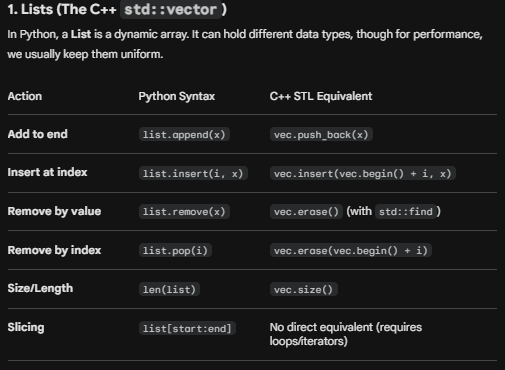

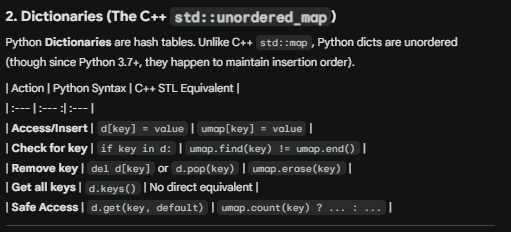

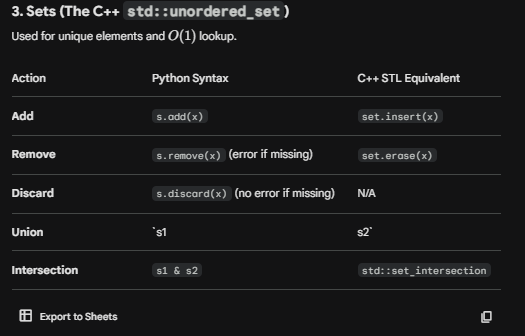

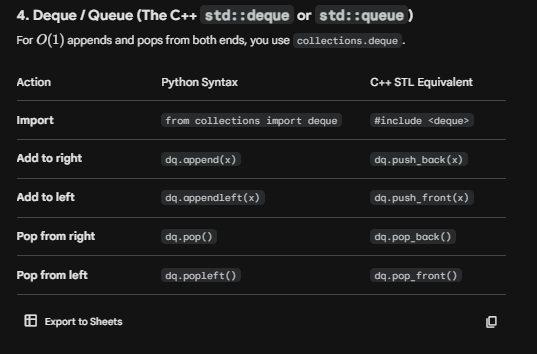

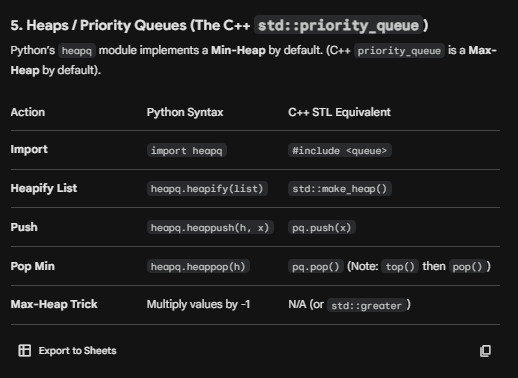
- import heapq
- data = [9, 8, 7, 5, 43, 2]
- heapq.heapify(data)
- print(data)
- a = heapq.heappop(data)
- print(a)
- heapq.heappush(data,1)
- print(data)

## water jug 
note use the tuples here intead of lists as in sets only tuples are accepted

In [6]:
from collections import deque

def waterjugbfs(jug1_cap, jug2_cap, target):
    # Use tuples (0, 0) for hashing in the set
    start_state = (0, 0)
    visited = {start_state}
    
    # Each entry in the queue is: (current_jug1, current_jug2, path_taken)
    q = deque([(0, 0, [start_state])])
    
    while q:
        c1, c2, path = q.popleft()
        
        # Goal check
        if c1 == target or c2 == target:
            return path
        
        # Define all possible moves as tuples
        moves = [
            (jug1_cap, c2),    # Fill Jug 1
            (c1, jug2_cap),    # Fill Jug 2
            (0, c2),           # Empty Jug 1
            (c1, 0),           # Empty Jug 2
            # Pour 1 -> 2
            (max(0, c1 - (jug2_cap - c2)), min(jug2_cap, c1 + c2)),
            # Pour 2 -> 1
            (min(jug1_cap, c1 + c2), max(0, c2 - (jug1_cap - c1)))
        ]
        
        for move in moves:
            if move not in visited:
                visited.add(move)
                # Create a NEW path list for this specific branch
                new_path = path + [move]
                q.append((move[0], move[1], new_path))
                
    return "No solution possible"

def waterjugdfs(jug1_cap, jug2_cap, target):
    visited = set()
    path = []

    def dfs(c1, c2):
        # 1. Check if we've already been in this specific state
        if (c1, c2) in visited:
            return False
        
        # 2. Mark state as visited and add to current path
        visited.add((c1, c2))
        path.append((c1, c2))

        # 3. Goal Test
        if c1 == target or c2 == target:
            return True

        # 4. Try all possible moves (Transitions)
        # Using a list of potential states to iterate through
        moves = [
            (jug1_cap, c2),           # Fill Jug 1
            (c1, jug2_cap),           # Fill Jug 2
            (0, c2),                  # Empty Jug 1
            (c1, 0),                  # Empty Jug 2
            # Pour 1 -> 2
            (max(0, c1 - (jug2_cap - c2)), min(jug2_cap, c1 + c2)),
            # Pour 2 -> 1
            (min(jug1_cap, c1 + c2), max(0, c2 - (jug1_cap - c1)))
        ]

        for next_s1, next_s2 in moves:
            if dfs(next_s1, next_s2):
                return True

        # 5. Backtrack: If none of the moves worked, remove from path
        path.pop()
        return False

    if dfs(0, 0):
        return path
    return "No solution"

print(waterjugbfs(4, 3, 2))
print(waterjugdfs(4, 3, 2))

[(0, 0), (0, 3), (3, 0), (3, 3), (4, 2)]
[(0, 0), (4, 0), (4, 3), (0, 3), (3, 0), (3, 3), (4, 2)]


## dfs and bfs

In [18]:
def bfs(graph,start,target):
    visited = {start}
    q = deque([(start,[start])])
    while q:
        node, path = q.popleft()
        if node ==target:
            return path
        for i in graph[node]:
            if i in visited: 
                continue
            visited.add(i)
            q.append((i,path+[i]))
    return False

def dfs_helper(graph , start, goal):
    visited = set()
    path = []
    def dfs(node):
        if node in visited :
            return False
        visited.add(node)
        #note here we have use methods and not path = path+[node] legb rules
        path.append(node)
        if node == goal:
            return True
        for i in graph[node]:
            if dfs(i):
                return True
        path.pop()
        return false
    if dfs(0):
        return path
    else :
        return False
                

graph = [
    [1,2,3,4],
    [2,3,5],
    [0,4,5],
    [2,0,1],
    [5],
    [2,3,4]
]
print(bfs(graph,0,5))
print(dfs_helper(graph,0,5))

[0, 1, 5]
[0, 1, 2, 4, 5]


## bidirectional with BFS

In [26]:
from collections import deque
def get_path(node,parent):
    path = []
    while node is not None:
        path.append(node)
        node = parent.get(node)
    return path[::-1]

def bidirectional_bfs(graph,start,goal):
    if start == goal :
        return [start]
    q_s = deque([start])
    q_e = deque([goal])
    par_s = {start:None}
    par_e = {goal:None}

    while q_s and q_e:
        # we need to no this level by level we can do this by the len of the qeuue
        for _ in range(len(q_s)):
            node = q_s.popleft()
            for neigh,cost in graph[node]:
                if neigh not in par_s:
                    par_s[neigh]= node
                    if neigh in par_e:
                        return get_path(neigh,par_s)+ get_path(neigh,par_e)[::-1][1:]
                    q_s.append(neigh)
        for _ in range(len(par_e)):
            node = q_e.popleft()
            for neigh,cost in graph[node]:
                if neigh not in par_e:
                    par_e[neigh]=node
                    if neigh in par_s:
                        return get_path(neigh,par_s)+ get_path(neigh,par_e)[::-1][1:]
                    q_e.append(neigh)
    return None
graph = {
    0: [(1, 1), (5, 1)],
    1: [(0, 1), (3, 1), (4, 1)],
    2: [(3, 1), (4, 1), (5, 1)],
    3: [(1, 1), (2, 1), (4, 1), (5, 1)],
    4: [(1, 1), (3, 1)],
    5: [(0, 1), (2, 1), (3, 1)]
}
print("Path:", bidirectional_bfs(graph, 0, 4))

Path: [0, 1, 4]


# uninformed algos


## uniform

In [30]:
import heapq
def uniform(graph,start,goal):
    parent = {start: None}
    heap = [(0,start)]
    heapq.heapify(heap)
    while(heap):
        n_cst, n = heapq.heappop(heap)
        if n == goal:
            return get_path(n,parent)
        for i,i_cst in graph[n]:
            if i not in parent:
                parent[i]=n
                heapq.heappush(heap,(n_cst+i_cst,i))
    return None
graph = {
    0: [(1, 2), (2, 5), (3, 1)],
    1: [(4, 3), (5, 8)],
    2: [(5, 2), (6, 4)],
    3: [(6, 7), (7, 3)],
    4: [(8, 6), (9, 2)],
    5: [(9, 1), (10, 5)],
    6: [(10, 2), (11, 9)],
    7: [(11, 4)],
    8: [(12, 3)],
    9: [(12, 6), (13, 2)],
    10: [(13, 7), (14, 3)],
    11: [(14, 1), (15, 4)],
    12: [(16, 5)],
    13: [(16, 2), (17, 6)],
    14: [(17, 3)],
    15: [(17, 8)],
    16: [(18, 4)],
    17: [(18, 2), (19, 7)],
    18: [(20, 3)],
    19: [(20, 1)],
    20: []
}
print(uniform(graph,0,17))

[0, 1, 4, 9, 13, 17]


## dls
1. The "Visited" Set Problem (Logic Error)In a standard DFS, a global visited set is fine. But in DLS, using a global visited set is dangerous.The Scenario: Suppose you reach "Node C" via a very long path at depth $k=4$ (your limit). You mark it as visited, but because you are at the limit, you can't explore its neighbors. You backtrack. Later, you find "Node C" again via a much shorter path (depth $k=1$).The Bug: Your code will see "Node C" in visited and skip it.The Consequence: You just missed the opportunity to explore "Node C's" children because you "wasted" the visit on a path that was too deep.

In [42]:
def dls(graph,start,goal,k):
    path = []
    def dls_runner(node,k):
        path.append(node)
        if node == goal:
            return True
        if k<=0:
            path.pop() #be sure to do this 
            return False
        for i,i_cost in graph[node]:
            if i not in path:
                if dls_runner(i,k-1):
                    return True
        path.pop()
    if dls_runner(0,k):
        return path
    else :
        print("not fount")

print(dls(graph,0,14,4))

[0, 1, 5, 10, 14]


## idls 

In [46]:
def idls(graph,start,goal):
    for i in range(goal):
        result = dls(graph,start,goal,i)
        if result:
            print(f"the path {result} was found at {i} depth")
            break
idls(graph,0,14)

not fount
not fount
not fount
not fount
the path [0, 1, 5, 10, 14] was found at 4 depth


In [54]:
from collections import deque
def bidirectional_dls(graph,start,goal):
    s_q = deque([start])
    g_q = deque([goal])
    s_p = {start:None}
    g_p = {goal:None}
    while s_q and g_q:
        found = expand_1_depth(graph,s_q,s_p,g_p)
        if found :
            return get_path(found,s_p)+ get_path(found,g_p)[::-1][1:]
        found = expand_1_depth(graph,g_q,g_p,s_p)
        if found :
            return get_path(found,s_p)+ get_path(found,g_p)[::-1][1:]
    return None

def expand_1_depth(graph,q,parent,other_parent):
    for _ in range(len(q)):
        crnt = q.popleft()
        for i,i_cost in graph[crnt]:
            if i not in parent:
                parent[i]=crnt
                q.append(i)
                if i in other_parent:
                    return i

    return None

print(bidirectional_dls(graph,0,15))

[0, 2, 6, 11, 15]


# informed searches 

In [70]:
# making a function to make the heuristic of a simple graph 
def make_heuristic(graph,goal):
    heuristic = {}
    q = deque([(0,0)])
    visited = {goal}
    while q :
        crnt, dist = q.popleft()
        heuristic[crnt]= dist
        for i,_ in graph[crnt]:
            if i not in visited:
                visited.add(i)
                q.append((i,dist+1))
    for i in graph :
        if i not in heuristic:
            heuristic[i] = -1
    return heuristic

heuristic15 = make_heuristic(graph,15)
print(heuristic15)

{0: 0, 1: 1, 2: 1, 3: 1, 4: 2, 5: 2, 6: 2, 7: 2, 8: 3, 9: 3, 10: 3, 11: 3, 12: 4, 13: 4, 14: 4, 16: 5, 17: 5, 18: 6, 19: 6, 20: 7, 15: -1}


## hill climbing

In [74]:
def hill_climbing(graph, start, goal, heuristic):
    current = start
    while True:
        neighs = graph[current]
        if not neighs: 
            break
        # Initialize with the first neighbor
        best_node = neighs[0][0] 
        
        # Look for the neighbor with the HIGHEST heuristic value
        for i, weight in neighs:
            if heuristic[i] > heuristic[best_node]:
                best_node = i
        
        # If the best neighbor is better than where we are, move there
        if heuristic[best_node] > heuristic[current]:
            current = best_node
        else:
            # We reached a peak (local maximum)
            break
            
    return current

# Note: Ensure your make_heuristic uses q = deque([(0, 0)]) 
# so that the values increase as you move away from 0 toward 15.
print(hill_climbing(graph, 0, 15, heuristic15))

20


In [97]:
import math,random
def simulated_annealing(graph, start, h):
    curr, temp = start, 0.9
    while temp > 0.1:
        neighbors = graph.get(curr, [])
        if not neighbors: break
        
        next_node = random.choice(neighbors)[0]
        delta = h[curr] - h[next_node] # Positive is good
        
        if delta > 0 or random.random() < math.exp(delta / temp):
            curr = next_node
            
        temp *= 0.95 # Cooling
    return curr

print(simulated_annealing(graph,0,heuristic15))

16


In [108]:
def beam_search(graph, start, goal, b, h):
    beam = [start]
    while beam:
        if goal in beam: return "Found"
        
        candidates = []
        for node in beam:
            for neighbor, cost in graph.get(node, []):
                candidates.append(neighbor)
        
        # Keep only the top B neighbors based on heuristic
        unique_candidates = list(set(candidates))
        beam = sorted(unique_candidates, key=lambda x: h[x])[:b]
    return "Not Found"

print(beam_search(graph, 0, 15, 4,heuristic15))

Found


## gbfs on grid


In [110]:
grid = [
    [1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 1],
    [1, 1, 1, 0, 1, 1, 0, 1, 0, 1],
    [0, 0, 1, 0, 1, 0, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 0, 1, 0, 0],
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 0, 1, 1, 1, 1, 0, 1, 1, 1],
    [1, 1, 1, 0, 0, 0, 1, 0, 0, 1]
]

In [114]:
start_point = [8, 0]
end_point = [0, 0]
def get_heuristic(row, col, dest):
    dist_r = row - dest[0]
    dist_c = col - dest[1]
    return (dist_r**2 + dist_c**2)**0.5

def gbfs(grid,src,goal):
    r,c = len(grid),len(grid[0])
    start_h = get_heuristic(src[0],src[1],goal)
    pq = [(start_h,src[0],src[1])]
    visited = {(src[0],src[1])}
    while pq:
        ch,cx,cy = heapq.heappop(pq)
        if(cx==goal[0] and cy ==goal[1]):
            return True
        moves = [
            (0,1),
            (1,0),
            (0,-1),
            (-1,0)
        ]
        for i in range(len(moves)):
            dr = moves[i][0]
            dc = moves[i][1]
            
            nr = r + dr
            nc = c + dc
            if 0 <= nr < r and 0 <= nc < c:
                if grid[nr][nc] == 1 and (nr, nc) not in visited:
                    visited.add((nr, nc))
                    h_val = get_heuristic(nr, nc, dest)
                    heapq.heappush(pq, (h_val, nr, nc))

result = gbfs(grid, start_point, end_point)

if result == True:
    print("Destination found")
else:
    print("Not found")

Not found


## a*on grid

In [117]:
def a_star(grid, src, dest):
    num_rows, num_cols = len(grid), len(grid[0])
    
    # Store the best G-score (actual cost) found so far for each node
    # visited = {(row, col): best_g}
    visited = {(src[0], src[1]): 0}
    
    start_h = get_heuristic(src[0], src[1], dest)
    # pq stores: (f_score, g_score, row, col)
    pq = [(start_h, 0, src[0], src[1])]
    
    while pq:
        f, g, r, c = heapq.heappop(pq)

        # If we reached the goal, we're done
        if r == dest[0] and c == dest[1]:
            return True

        # If we already found a shorter path to this specific node, skip this expansion
        if g > visited.get((r, c), float('inf')):
            continue

        for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
            nr, nc = r + dr, c + dc
            
            if 0 <= nr < num_rows and 0 <= nc < num_cols and grid[nr][nc] == 1:
                new_g = g + 1
                
                # Check if this new path to (nr, nc) is better than any we've seen
                if new_g < visited.get((nr, nc), float('inf')):
                    visited[(nr, nc)] = new_g
                    f_val = new_g + get_heuristic(nr, nc, dest)
                    heapq.heappush(pq, (f_val, new_g, nr, nc))
                        
    return False


if a_star(grid, [8, 0], [0, 0]):
    print("Destination found")
else:
    print("Not found")

Destination found


## puzzle problem with A*

In [126]:
import heapq
class Node:
    def __init__(self,mat,x,y,g_n,parent,final):
        self.mat = mat
        self.x = x  # Row of blank space
        self.y = y  # Col of blank space
        self.g_n = g_n # level
        self.parent = parent
        # Calculate h(n) immediately upon creation
        self.final = final
        self.h_cost = self._calculate_misplaced_tiles()
        self.f_cost = self.g_n + self.h_cost
    def _calculate_misplaced_tiles(self):
        ct = 0 ;
        for i in range(3):
            for j in range(3):
                if self.mat[i][j]!=0 and self.mat[i][j]==self.final[i][j]:
                    ct+=1

        return ct;
    def _safe(self,i,j):
        return i>=0 and i<3 and j>=0 and j<3
    def moves(self):
        ans = []
        delta = [
            (1,0),
            (-1,0),
            (0,-1),
            (0,1)
        ]
        for di,dj in delta:
            if self._safe(di+self.x,dj+self.y):
                nx = di+self.x
                ny = dj+self.y
                new_mat = [list(row) for row in self.mat]
                # swapping
                new_mat[self.x][self.y], new_mat[nx][ny] = \
                    new_mat[nx][ny], new_mat[self.x][self.y]
                child = Node(new_mat,nx,ny,self.g_n+1,self,final)
                ans.append(child)

        return ans
    def __lt__(self,other):
        return self.h_cost<other.h_cost
    def print_state(self):
        for row in self.mat:
            print(' '.join(map(str, row)))
        print()
    

def solve(intial,start_x,start_y,final):
    pq = []
    root = Node(intial,start_x,start_y,0,None,final)
    heapq.heappush(pq,root)
    visited = set()
    while pq:
        crnt = heapq.heappop(pq)
        state = tuple(tuple(row) for row in crnt.mat)
        visited.add(state)

        if crnt.h_cost==0:
            print_path(crnt)
            return

        for child in crnt.moves():
            if tuple(tuple(row) for row in child.mat) not in visited:
                heapq.heappush(pq,child)
        
def print_path(node):
    if node is None:
        return
    print_path(node.parent)
    node.print_state()      
    
initial = [
    [1, 8, 2],
    [3, 4, 5],
    [6, 0, 7]
]

final = [
    [0, 1, 2],
    [3, 4, 5],
    [6, 7, 8]
]

# Note: The '0' in the initial grid is at row 2, col 1
solve(initial, 2, 1, final)            

1 8 2
3 4 5
6 0 7

1 8 2
3 0 5
6 4 7

1 8 2
0 3 5
6 4 7

1 8 2
6 3 5
0 4 7

1 8 2
6 3 5
4 0 7

1 8 2
6 0 5
4 3 7

1 8 2
6 5 0
4 3 7

1 8 0
6 5 2
4 3 7



# adversial

## minimax of tictactoe

In [132]:
class TicTacToeAI:  # Renamed to match your instantiation at the bottom
    def __init__(self, ai_player='X', human_player='O'):
        self.ai = ai_player
        self.human = human_player
        self.empty = '_'

    def eval(self, board):
        # Check rows and columns
        for i in range(3):
            if board[i][0] == board[i][1] == board[i][2] and board[i][0] != self.empty:
                return 10 if board[i][0] == self.ai else -10
            if board[0][i] == board[1][i] == board[2][i] and board[0][i] != self.empty:
                return 10 if board[0][i] == self.ai else -10

        # Check diagonals
        if board[0][0] == board[1][1] == board[2][2] and board[0][0] != self.empty:
            return 10 if board[0][0] == self.ai else -10
        if board[0][2] == board[1][1] == board[2][0] and board[0][2] != self.empty:
            return 10 if board[0][2] == self.ai else -10

        return 0

    def is_moves_left(self, board):
        return any(self.empty in row for row in board)

    def minimax(self, board, depth, is_maxing):
        score = self.eval(board)
        
        if score == 10 or score == -10:
            return score
        if not self.is_moves_left(board):
            return 0

        if is_maxing:
            best = -float('inf')
            for r in range(3):
                for c in range(3):
                    if board[r][c] == self.empty:
                        board[r][c] = self.ai  # FIX: Use '=' not '=='
                        best = max(best, self.minimax(board, depth + 1, False))
                        board[r][c] = self.empty  # Backtrack!
            return best
        else:
            best = float('inf')
            for r in range(3):
                for c in range(3):
                    if board[r][c] == self.empty:
                        board[r][c] = self.human  # FIX: Use '=' not '=='
                        # FIX: Use min() for the human player
                        best = min(best, self.minimax(board, depth + 1, True))
                        board[r][c] = self.empty  # Backtrack!
            return best

    def get_best_move(self, board): # Renamed to match your call
        best_val = -float('inf')
        move = (-1, -1)

        for r in range(3):
            for c in range(3):
                if board[r][c] == self.empty:
                    board[r][c] = self.ai
                    move_val = self.minimax(board, 0, False)
                    board[r][c] = self.empty
                    
                    if move_val > best_val:
                        best_val = move_val
                        move = (r, c)
        return move

# --- Execution ---
game_board = [
    ['O', 'X', 'X'],
    ['_', 'O', '_'],
    ['_', '_', '_']
]

engine = TicTacToeAI()
best_move = engine.get_best_move(game_board)

print(f"AI Strategy: Move to Row {best_move[0]}, Col {best_move[1]}")

AI Strategy: Move to Row 2, Col 2


## alpha beta pruning 

In [134]:
import math

class TicTacToeAI:
    def __init__(self, ai_player='X', human_player='O'):
        self.ai = ai_player
        self.human = human_player
        self.empty = '_'

    def eval(self, board):
        for i in range(3):
            if board[i][0] == board[i][1] == board[i][2] and board[i][0] != self.empty:
                return 10 if board[i][0] == self.ai else -10
            if board[0][i] == board[1][i] == board[2][i] and board[0][i] != self.empty:
                return 10 if board[0][i] == self.ai else -10
        if board[0][0] == board[1][1] == board[2][2] and board[0][0] != self.empty:
            return 10 if board[0][0] == self.ai else -10
        if board[0][2] == board[1][1] == board[2][0] and board[0][2] != self.empty:
            return 10 if board[0][2] == self.ai else -10
        return 0

    def is_moves_left(self, board):
        return any(self.empty in row for row in board)

    def minimax(self, board, depth, alpha, beta, is_maxing):
        score = self.eval(board)
        if score == 10 or score == -10: return score
        if not self.is_moves_left(board): return 0

        if is_maxing:
            best = -float('inf')
            for r in range(3):
                for c in range(3):
                    if board[r][c] == self.empty:
                        board[r][c] = self.ai
                        best = max(best, self.minimax(board, depth + 1, alpha, beta, False))
                        board[r][c] = self.empty
                        
                        # Alpha-Beta Logic
                        alpha = max(alpha, best)
                        if beta <= alpha:
                            break # Prune
                if beta <= alpha: break
            return best
        else:
            best = float('inf')
            for r in range(3):
                for c in range(3):
                    if board[r][c] == self.empty:
                        board[r][c] = self.human
                        best = min(best, self.minimax(board, depth + 1, alpha, beta, True))
                        board[r][c] = self.empty
                        
                        # Alpha-Beta Logic
                        beta = min(beta, best)
                        if beta <= alpha:
                            break # Prune
                if beta <= alpha: break
            return best

    def get_best_move(self, board):
        best_val = -float('inf')
        move = (-1, -1)
        # Initial Alpha and Beta
        alpha = -float('inf')
        beta = float('inf')

        for r in range(3):
            for c in range(3):
                if board[r][c] == self.empty:
                    board[r][c] = self.ai
                    # Start minimax with alpha and beta
                    move_val = self.minimax(board, 0, alpha, beta, False)
                    board[r][c] = self.empty
                    
                    if move_val > best_val:
                        best_val = move_val
                        move = (r, c)
        return move

## chekcers with minimax depth of 2

In [136]:
class Checkers:
    def __init__(self):
        # 8x8 board: 1 (Player 1), -1 (Player 2), 0 (Empty)
        self.board = self.create_board()
        self.p1 = 1
        self.p2 = -1

    def create_board(self):
        board = [[0] * 8 for _ in range(8)]
        for r in range(8):
            for c in range(8):
                if (r + c) % 2 != 0: # Only dark squares
                    if r < 3: board[r][c] = 1   # Player 1 top
                    elif r > 4: board[r][c] = -1 # Player 2 bottom
        return board

    def evaluate(self, board):
        # Simple evaluation: count pieces
        score = 0
        for r in board:
            score += sum(r)
        return score # Positive favors P1, Negative favors P2
    def get_valid_moves(self, board, player):
        moves = []
        direction = 1 if player == 1 else -1
        
        for r in range(8):
            for c in range(8):
                if board[r][c] == player:
                    # Check standard diagonal moves
                    for dc in [-1, 1]:
                        nr, nc = r + direction, c + dc
                        if 0 <= nr < 8 and 0 <= nc < 8:
                            if board[nr][nc] == 0:
                                moves.append(((r, c), (nr, nc)))
                            # Check jumps (Captures)
                            elif board[nr][nc] == -player:
                                jr, jc = nr + direction, nc + dc
                                if 0 <= jr < 8 and 0 <= jc < 8 and board[jr][jc] == 0:
                                    moves.append(((r, c), (jr, jc)))
        return moves

    def make_move(self, board, move):
        # move is ((start_r, start_c), (end_r, end_c))
        new_board = [row[:] for row in board]
        (sr, sc), (er, ec) = move
        piece = new_board[sr][sc]
        new_board[er][ec] = piece
        new_board[sr][sc] = 0
        
        # If it was a jump, remove the middle piece
        if abs(sr - er) == 2:
            new_board[(sr + er) // 2][(sc + ec) // 2] = 0
        return new_board
    def minimax(self, board, depth, alpha, beta, is_maxing):
        if depth == 0:
            return self.evaluate(board)
        
        player = self.p1 if is_maxing else self.p2
        moves = self.get_valid_moves(board, player)
        
        if not moves: # No moves left
            return self.evaluate(board)

        if is_maxing:
            best = -float('inf')
            for move in moves:
                temp_board = self.make_move(board, move)
                best = max(best, self.minimax(temp_board, depth - 1, alpha, beta, False))
                alpha = max(alpha, best)
                if beta <= alpha: break
            return best
        else:
            best = float('inf')
            for move in moves:
                temp_board = self.make_move(board, move)
                best = min(best, self.minimax(temp_board, depth - 1, alpha, beta, True))
                beta = min(beta, best)
                if beta <= alpha: break
            return best
    def get_best_move(self, board):
        best_val = -float('inf')
        best_move = None
        moves = self.get_valid_moves(board, self.p1)
        for move in moves:
            temp = self.make_move(board, move)
            val = self.minimax(temp, 3, -float('inf'), float('inf'), False)
            if val > best_val:
                best_val = val
                best_move = move
        return best_move

    def print_board(self, board):
        print("  0 1 2 3 4 5 6 7")
        for i, row in enumerate(board):
            display_row = [('B' if x == 1 else 'W' if x == -1 else '.') for x in row]
            print(f"{i} {' '.join(display_row)}")

## unification

In [138]:
def unify(expr1, expr2, substitution=None):
    if substitution is None:
        substitution = {}

    # If expressions are identical, we are done
    if expr1 == expr2:
        return substitution

    # If expr1 is a variable (represented as a string starting with '?')
    if isinstance(expr1, str) and expr1.startswith('?'):
        return unify_variable(expr1, expr2, substitution)

    # If expr2 is a variable
    if isinstance(expr2, str) and expr2.startswith('?'):
        return unify_variable(expr2, expr1, substitution)

    # If both are lists (complex expressions like ['parent', 'Hisham', '?x'])
    if isinstance(expr1, list) and isinstance(expr2, list):
        if len(expr1) != len(expr2):
            return None
        # Recursively unify the first elements, then the rest
        new_sub = unify(expr1[0], expr2[0], substitution)
        if new_sub is None:
            return None
        return unify(expr1[1:], expr2[1:], new_sub)

    # Otherwise, they cannot be unified
    return None

def unify_variable(var, val, substitution):
    if var in substitution:
        # If the variable is already bound, unify its value with the new val
        return unify(substitution[var], val, substitution)
    elif val in substitution:
        # If the value is a variable and already bound
        return unify(var, substitution[val], substitution)
    else:
        # Create a new binding
        substitution[var] = val
        return substitution

# --- Testing the Code ---
exp1 = ["parent", "Hisham", "?child"]
exp2 = ["parent", "?father", "Ahmed"]

result = unify(exp1, exp2)

if result:
    print(f"Unification Successful!")
    print(f"Bindings: {result}")
else:
    print("Unification Failed.")

Unification Successful!
Bindings: {'?father': 'Hisham', '?child': 'Ahmed'}


## bayesian betwork

In [139]:
class BayesianNode:
    def __init__(self, name, parents=None, cpt=None):
        self.name = name
        self.parents = parents or []
        self.cpt = cpt or {} # Maps parent states to probabilities

    def get_prob(self, state, parent_states):
        """
        Returns P(Node=state | Parents=parent_states)
        parent_states: a tuple of boolean values corresponding to self.parents
        """
        prob_true = self.cpt.get(parent_states, 0)
        return prob_true if state else 1 - prob_true

class BayesianNetwork:
    def __init__(self):
        self.nodes = {}

    def add_node(self, node):
        self.nodes[node.name] = node

    def calculate_joint_prob(self, event):
        """
        Calculates P(X1, X2, ..., Xn) using the Chain Rule:
        P(X1...Xn) = Product of P(Xi | Parents(Xi))
        event: {'Rain': True, 'Sprinkler': False, 'GrassWet': True}
        """
        joint_prob = 1.0
        for name, node in self.nodes.items():
            # Get the states of this node's parents from the event dict
            # If the event is {'Rain': True, 'Sprinkler': False}, it creates a tuple (True, False)
            parent_states = tuple(event[p] for p in node.parents)
            joint_prob *= node.get_prob(event[name], parent_states)
        return joint_prob

# --- Example: The Classic "Rain/Sprinkler" Model ---
# P(Rain) = 0.2
rain = BayesianNode("Rain", cpt={(): 0.2})

# P(Sprinkler | Rain): If it rains, sprinkler is less likely (0.01 vs 0.4)
sprinkler = BayesianNode("Sprinkler", parents=["Rain"], cpt={
    (True,): 0.01,
    (False,): 0.4
})

# P(GrassWet | Rain, Sprinkler)
grass_wet = BayesianNode("GrassWet", parents=["Rain", "Sprinkler"], cpt={
    (True, True): 0.99,
    (True, False): 0.8,
    (False, True): 0.9,
    (False, False): 0.0
})

network = BayesianNetwork()
for n in [rain, sprinkler, grass_wet]: network.add_node(n)

# Scenario: What is the probability it is Raining, Sprinkler is OFF, and Grass is WET?
scenario = {"Rain": True, "Sprinkler": False, "GrassWet": True}
prob = network.calculate_joint_prob(scenario)

print(f"Probability of the scenario: {prob:.4f}")

Probability of the scenario: 0.1584
